# 1. ⚙️ Instalasi dan Impor Library

In [ ]:
!pip install tensorflow
!pip install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

# Library untuk Scaling dan Metrik
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Library untuk Deep Learning (LSTM)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 2. 📤 Mengunggah dan Membaca Data

In [ ]:
print("Silakan upload file data Anda (Excel atau CSV)...")
uploaded = files.upload()
nama_file = list(uploaded.keys())[0]

try:
    if nama_file.endswith('.csv'):
        data = pd.read_csv(io.BytesIO(uploaded[nama_file]))
    elif nama_file.endswith('.xlsx'):
        data = pd.read_excel(io.BytesIO(uploaded[nama_file]))
    print(f"Sukses membaca file: {nama_file}")

    # GANTI NAMA KOLOM INI SESUAI FILE ANDA
    NAMA_KOLOM_TANGGAL = 'Periode'
    NAMA_KOLOM_JUMLAH = 'Jumlah_Pengunjung'

except Exception as e:
    print(f"Gagal membaca file. Error: {e}")



Silakan upload file data Anda (Excel atau CSV)...


Saving pengunjung_time_series.csv to pengunjung_time_series (3).csv
Sukses membaca file: pengunjung_time_series (3).csv


# 3. 🧹 Pra-pemrosesan & Normalisasi Data (Kritis!)

In [ ]:
# 3.1. Ambil HANYA kolom jumlah wisatawan
try:
    # Pastikan data diurutkan berdasarkan tanggal
    data[NAMA_KOLOM_TANGGAL] = pd.to_datetime(data[NAMA_KOLOM_TANGGAL])
    data = data.sort_values(by=NAMA_KOLOM_TANGGAL)

    # Ambil nilai dan ubah jadi float
    dataset = data[NAMA_KOLOM_JUMLAH].values.astype('float32').reshape(-1, 1)

    # Simpan tanggal untuk plotting nanti
    dates = data[NAMA_KOLOM_TANGGAL]

except Exception as e:
    print(f"Gagal memproses. Pastikan nama kolom benar. Error: {e}")

# 3.2. Bagi data (RAW) menjadi train dan test SEBELUM scaling
# Ini adalah cara paling 'aman' untuk mencegah data leakage
split_point = len(dataset) - 20 # 12 bulan terakhir untuk test
train_data_raw = dataset[:split_point]
test_data_raw = dataset[split_point:]

print(f"Jumlah data train: {len(train_data_raw)}")
print(f"Jumlah data test: {len(test_data_raw)}")

# 3.3. Buat dan Fit Scaler HANYA pada data train
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_data_raw)

# 3.4. Transform (Scale) data train dan test
train_scaled = scaler.transform(train_data_raw)
test_scaled = scaler.transform(test_data_raw)

Jumlah data train: 312
Jumlah data test: 20


4. 🔄 Membuat Urutan "Time Steps"

In [ ]:
  # Fungsi untuk membuat sekuens
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Tentukan berapa bulan ke belakang untuk prediksi (time steps)
look_back = 12

# 4.1. Buat sekuens untuk data TRAIN
X_train, y_train = create_dataset(train_scaled, look_back)

# 4.2. Buat sekuens untuk data TEST
# PENTING: Kita butuh 12 data terakhir dari train_scaled untuk memprediksi
# data pertama dari test_scaled.
temp_input = np.concatenate((train_scaled[-look_back:], test_scaled))
X_test, y_test = create_dataset(temp_input, look_back)

print(f"Shape X_train: {X_train.shape}") # (jumlah sampel, 12 time steps)
print(f"Shape y_train: {y_train.shape}")
print(f"Shape X_test: {X_test.shape}")   # (12 sampel, 12 time steps)
print(f"Shape y_test: {y_test.shape}")   # (12,)


Shape X_train: (300, 12)
Shape y_train: (300,)
Shape X_test: (20, 12)
Shape y_test: (20,)


# 5. 🧱 Membangun Model LSTM

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import time
import random
import os

def set_seed(seed=100):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(100)

# 5.2. Buat Fungsi Pembangun Model

def build_lstm_model(neuron_count, input_shape, learning_rate):
    model = Sequential()
    model.add(LSTM(neuron_count, input_shape=input_shape))
    model.add(Dense(1))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    return model

# 5.3. Tentukan Parameter Grid Search Anda
neurons_list = [50]
epochs_list = [50, 100]
batch_size_list = [16, 32, 64]
learning_rate_list = [0.01, 0.001] # <-- TAMBAHKAN LIST LEARNING RATE

# Hitung total kombinasi baru
total_experiments = len(neurons_list) * len(epochs_list) * len(batch_size_list) * len(learning_rate_list)
print(f"Memulai Grid Search Manual untuk {total_experiments} kombinasi...")
print(f"  Neurons: {neurons_list}")
print(f"  Epochs: {epochs_list}")
print(f"  Batch Sizes: {batch_size_list}")
print(f"  Learning Rates: {learning_rate_list}") # <-- Tampilkan LR
print("Ini akan memakan waktu JAUH lebih lama...")

results = []
best_run = {'mape': float('inf')}
experiment_count = 0
start_time_total = time.time()

# 5.4. Latih Model (Loop Grid Search 4 TINGKAT)
for neurons in neurons_list:
    for epochs in epochs_list:
        for batch_size in batch_size_list:
            for learning_rate in learning_rate_list: # <-- TAMBAHKAN LOOP LR

                experiment_count += 1
                start_time_exp = time.time()

                # Buat nama unik untuk kombinasi ini
                exp_name = f"{neurons}N, {epochs}E, {batch_size}B, {learning_rate}LR" # <-- Tambah LR ke nama
                print(f"\n--- ({experiment_count}/{total_experiments}) Menjalankan: {exp_name} ---")

                # Bangun model
                model = build_lstm_model(neurons, (look_back, 1), learning_rate) # <-- Kirim LR ke fungsi

                # Latih model
                history = model.fit(
                    X_train,
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_test, y_test),
                    verbose=0,
                    shuffle=False
                )

                # 6.1. Buat prediksi
                test_predict_scaled = model.predict(X_test, verbose=0)

                # ... (sisa kode 6.2, 6.3, 6.4, dan penyimpanan 'results' sama persis) ...

                # 6.2. Invers-transform prediksi
                test_predict_actual = scaler.inverse_transform(test_predict_scaled)

                # 6.3. Invers-transform y_test (data asli)
                y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

                # 6.4. Hitung Metrik Evaluasi
                mape = mean_absolute_percentage_error(y_test_actual, test_predict_actual)
                mae = mean_absolute_error(y_test_actual, test_predict_actual)
                rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict_actual))

                exp_time = time.time() - start_time_exp
                print(f"  Hasil MAPE: {mape * 100:.2f}% (Waktu: {exp_time:.1f} detik)")

                # Simpan hasil
                results.append({
                    'Kombinasi': exp_name,
                    'MAPE (%)': mape * 100,
                    'MAE': mae,
                    'RMSE': rmse,
                    'Neurons': neurons,
                    'Epochs': epochs,
                    'Batch Size': batch_size,
                    'Learning Rate': learning_rate # <-- Simpan LR
                })

                # Cek dan simpan jika ini model terbaik
                if mape < best_run['mape']:
                    print(f"  ==> Model Terbaik Baru Ditemukan!")
                    best_run['mape'] = mape
                    best_run['name'] = exp_name
                    best_run['history'] = history.history
                    best_run['predictions'] = test_predict_actual

# ... (sisa kode (Blok 7) untuk menampilkan tabel dan plot SAMA PERSIS) ...

end_time_total = time.time()
print(f"\n\n--- Selesai Grid Search ---")
print(f"Total waktu: {(end_time_total - start_time_total) / 60:.2f} menit")

# 7.1. Tampilkan Tabel Perbandingan
print("\n--- Tabel Perbandingan Hasil Tuning (Diurutkan berdasarkan MAPE) ---")
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='MAPE (%)')
# Tampilkan 5 terbaik
print(df_results.head(5).to_markdown(index=False, floatfmt=".2f"))

Memulai Grid Search Manual untuk 12 kombinasi...
  Neurons: [50]
  Epochs: [50, 100]
  Batch Sizes: [16, 32, 64]
  Learning Rates: [0.01, 0.001]
Ini akan memakan waktu JAUH lebih lama...

--- (1/12) Menjalankan: 50N, 50E, 16B, 0.01LR ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Hasil MAPE: 7.49% (Waktu: 30.3 detik)
  ==> Model Terbaik Baru Ditemukan!

--- (2/12) Menjalankan: 50N, 50E, 16B, 0.001LR ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Hasil MAPE: 9.02% (Waktu: 19.0 detik)

--- (3/12) Menjalankan: 50N, 50E, 32B, 0.01LR ---


...

  Hasil MAPE: 9.07% (Waktu: 19.3 detik)

--- (11/12) Menjalankan: 50N, 100E, 64B, 0.01LR ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Hasil MAPE: 8.20% (Waktu: 17.3 detik)

--- (12/12) Menjalankan: 50N, 100E, 64B, 0.001LR ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Hasil MAPE: 10.01% (Waktu: 16.3 detik)


--- Selesai Grid Search ---
Total waktu: 3.63 menit

--- Tabel Perbandingan Hasil Tuning (Diurutkan berdasarkan MAPE) ---
| Kombinasi               |   MAPE (%) |      MAE |      RMSE |   Neurons |   Epochs |   Batch Size |   Learning Rate |
|:------------------------|-----------:|---------:|----------:|----------:|---------:|-------------:|----------------:|
| 50N, 50E, 16B, 0.01LR   |       7.49 | 83686.38 | 103565.95 |        50 |       50 |           16 |            0.01 |
| 50N, 100E, 16B, 0.001LR |       7.53 | 86998.50 | 105785.55 |        50 |      100 |           16 |            0.00 |
| 50N, 50E, 64B, 0.01LR   |       7.54 | 87408.36 | 104220.69 |        50 |       50 |           64 |            0.01 |
| 50N, 100E, 32B, 0.01LR  |       7.62 | 85915.99 | 106403.39 |        50 |      100 |           32 |            0.01 |
| 50N, 50E, 32B, 0.01LR   |       7.81 | 90256.86 | 105109.74 |        50 |       50 |           32 |            0.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import time
import random
import os

def set_seed(seed=100):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(100)

# 5.2. Buat Fungsi Pembangun Model
def build_lstm_model(neuron_count, input_shape, learning_rate):
    model = Sequential()
    model.add(LSTM(neuron_count, input_shape=input_shape))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    return model


# 5.3. Tentukan Parameter Grid Search Anda
neurons_list = [50]
epochs_list = [50, 100]
batch_size_list = [16, 32, 64]
learning_rate_list = [0.01, 0.001]

total_experiments = len(neurons_list) * len(epochs_list) * len(batch_size_list) * len(learning_rate_list)
print(f"Memulai Grid Search Manual untuk {total_experiments} kombinasi...")

results = []
best_run = {'mape': float('inf')}
experiment_count = 0
start_time_total = time.time()

model_id = 0

# ==============================
# LOOP GRID SEARCH
# ==============================
for neurons in neurons_list:
    for epochs in epochs_list:
        for batch_size in batch_size_list:
            for learning_rate in learning_rate_list:

                model_id += 1
                experiment_count += 1
                print(f"\nMenjalankan Model {model_id} ...")

                # Bangun model
                model = build_lstm_model(neurons, (look_back, 1), learning_rate)

                # Latih model
                history = model.fit(
                    X_train,
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_test, y_test),
                    verbose=0,
                    shuffle=False
                )

                # --- Rata-rata training loss & val loss ---
                avg_loss = float(np.mean(history.history['loss']))
                avg_val_loss = float(np.mean(history.history['val_loss']))

                # Prediksi
                test_predict_scaled = model.predict(X_test, verbose=0)
                test_predict_actual = scaler.inverse_transform(test_predict_scaled)
                y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

                # METRIK
                mape = mean_absolute_percentage_error(y_test_actual, test_predict_actual)
                mae = mean_absolute_error(y_test_actual, test_predict_actual)
                rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict_actual))

                # === SIMPAN KE TABEL ===
                results.append({
                    'Model': model_id,
                    'Batch Size': batch_size,
                    'Epoch': epochs,
                    'Learning Rate': learning_rate,
                    'Rata-rata Loss': avg_loss,
                    'Rata-rata Val Loss': avg_val_loss,
                    'MAPE (%)': mape * 100,
                    'MAE': mae,
                    'RMSE': rmse
                })

                # Simpan sebagai best model
                if mape < best_run['mape']:
                    best_run['mape'] = mape
                    best_run['name'] = f"{neurons}N {epochs}E {batch_size}B {learning_rate}LR"
                    best_run['history'] = history.history
                    best_run['predictions'] = test_predict_actual


# ==============================
# Tampilkan Hasil
# ==============================
end_time_total = time.time()
print(f"\n--- Grid Search Selesai dalam {(end_time_total - start_time_total) / 60:.2f} menit ---")

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Model')  # urut sesuai nomor model

print("\n--- HASIL LENGKAP SELURUH MODEL (URUT SESUAI NOMOR) ---")
print(df_results.to_markdown(index=False, floatfmt=".4f"))

Memulai Grid Search Manual untuk 12 kombinasi...

Menjalankan Model 25 ...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Menjalankan Model 26 ...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Menjalankan Model 27 ...


...


Menjalankan Model 35 ...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Menjalankan Model 36 ...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Grid Search Selesai dalam 3.44 menit ---

--- HASIL LENGKAP SELURUH MODEL (URUT SESUAI NOMOR) ---
|   Model |   Batch Size |    Epoch |   Learning Rate |   Rata-rata Loss |   Rata-rata Val Loss |   MAPE (%) |         MAE |        RMSE |
|--------:|-------------:|---------:|----------------:|-----------------:|---------------------:|-----------:|------------:|------------:|
| 25.0000 |      16.0000 |  50.0000 |          0.0100 |           0.0056 |               0.0094 |     7.4883 |  83686.3750 | 103565.9471 |
| 26.0000 |      16.0000 |  50.0000 |          0.0010 |           0.0071 |               0.0122 |     9.0232 | 108009.7734 | 130527.2626 |
| 27.0000 |      32.0000 |  50.0000 |          0.0100 |           0.0055 |               0.0081 |     7.8099 |  90256.8594 | 105109.7371 |
| 28.0000 |      32.0000 |  50.0000 |          0.0010 |           0.0080 |               0.0143 |    10.1387 | 123142.3281 | 146431.7902 |
| 29.0000 |      64.0000 |  50.0000 |          0.0100 |        

# 7. 📉 Plot Diagnostik (Test Set)


--- Plot Diagnostik untuk Model Terbaik: 50N 50E 16B 0.01LR ---


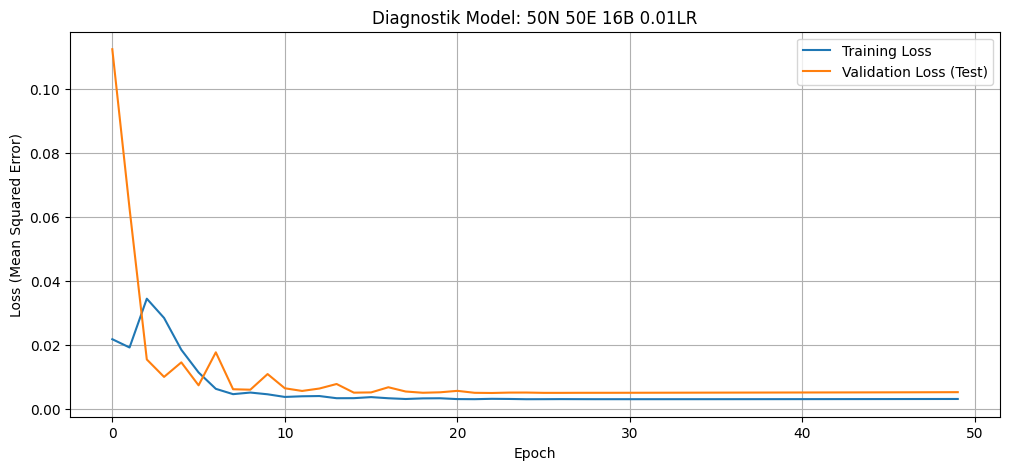


--- Plot Prediksi untuk Model Terbaik: 50N 50E 16B 0.01LR ---


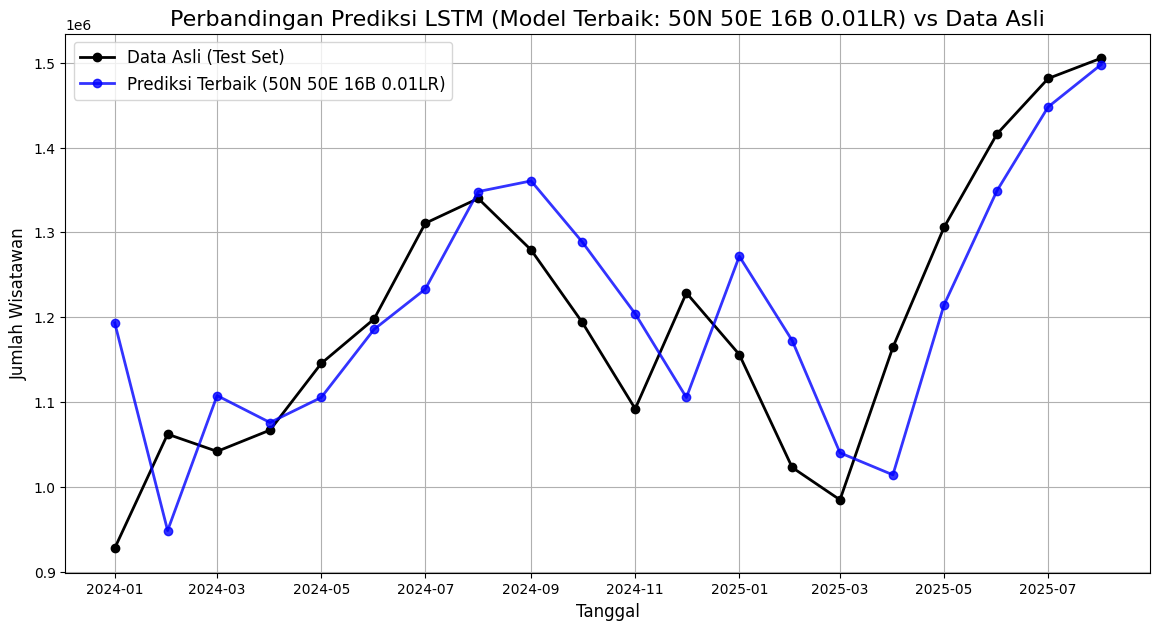

In [ ]:
# 7.2. Tampilkan Plot Diagnostik untuk Model TERBAIK
print(f"\n--- Plot Diagnostik untuk Model Terbaik: {best_run['name']} ---")

best_history = best_run['history']

plt.figure(figsize=(12, 5))
plt.plot(best_history['loss'], label='Training Loss')
plt.plot(best_history['val_loss'], label='Validation Loss (Test)')
plt.title(f'Diagnostik Model: {best_run["name"]}')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()


# 7.3. Tampilkan Plot Prediksi untuk Model TERBAIK
print(f"\n--- Plot Prediksi untuk Model Terbaik: {best_run['name']} ---")

plt.figure(figsize=(14, 7))

# Ambil tanggal untuk test set (asumsi 'dates' dan 'split_point' ada)
test_dates = dates.iloc[split_point:]

# Plot data ASLI (observasi) dari test set
plt.plot(test_dates,
         y_test_actual,
         'ko-',
         label='Data Asli (Test Set)',
         linewidth=2)

# Plot data PREDIKSI (forecast) dari model terbaik
plt.plot(test_dates,
         best_run['predictions'],
         'b-o',
         label=f"Prediksi Terbaik ({best_run['name']})",
         linewidth=2,
         alpha=0.8)

plt.title(f"Perbandingan Prediksi LSTM (Model Terbaik: {best_run['name']}) vs Data Asli", fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Jumlah Wisatawan', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# 8. 📉 Plot Gabungan (Train + Test)

In [ ]:
# 5.1. Reshape X_train dan X_test menjadi [samples, time_steps, features]
# LSTM membutuhkannya dalam 3D. Fitur kita = 1.
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Shape 3D X_train: {X_train.shape}")
print(f"Shape 3D X_test: {X_test.shape}")

# 5.2. Bangun arsitektur model
model = Sequential()
model.add(LSTM(50, input_shape=(look_back, 1))) # 50 neuron, input_shape=(12, 1)
model.add(Dense(1)) # 1 neuron output (untuk prediksi)
my_optimizer = Adam(learning_rate=0.01)
model.compile(loss='mean_squared_error', optimizer=my_optimizer)

print("\nRingkasan Model LSTM:")
model.summary()

# 5.3. Latih model!
# Epochs = berapa kali model "melihat" seluruh data.
print("\nMelatih model LSTM... (Ini mungkin perlu beberapa menit)")
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1,
    shuffle=False
)

Shape 3D X_train: (300, 12, 1)
Shape 3D X_test: (20, 12, 1)

Ringkasan Model LSTM:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_75"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_75 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


Melatih model LSTM... (Ini mungkin perlu beberapa menit)
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0102 - val_loss: 0.0844
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0058 - val_loss: 0.0907
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0117 - val_loss: 0.0619
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0138 - val_loss: 0.0094
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0284 - val_loss: 0.0070
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0178 - val_loss: 0.0064
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0036 - val_loss: 0.0167
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0038 - val_loss: 0.0072
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0031 - val_loss: 0.0060
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0033 - val_loss: 0.0081
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0020 - val_loss: 0.0088
Epoch

In [ ]:
# 6.1. Buat prediksi pada data test
test_predict_scaled = model.predict(X_test)

# 6.2. Invers-transform: Kembalikan prediksi dari 0-1 ke jumlah wisatawan asli
test_predict_actual = scaler.inverse_transform(test_predict_scaled)

# 6.3. Invers-transform: Kembalikan y_test (data asli)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# 6.4. Hitung Metrik Evaluasi
mae_asli = mean_absolute_error(y_test_actual, test_predict_actual)
rmse_asli = np.sqrt(mean_squared_error(y_test_actual, test_predict_actual))
mape_asli = mean_absolute_percentage_error(y_test_actual, test_predict_actual)

print(f"\n--- Metrik Test Set (LSTM) ---")
print(f"MAE (Jumlah Wisatawan): {mae_asli:,.0f}")
print(f"RMSE (Jumlah Wisatawan): {rmse_asli:,.0f}")
print(f"MAPE: {mape_asli * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step

--- Metrik Test Set (LSTM) ---
MAE (Jumlah Wisatawan): 83,788
RMSE (Jumlah Wisatawan): 103,008
MAPE: 7.48%


In [ ]:
# 1.1. Buat prediksi pada data TRAINING
train_predict_scaled = model.predict(X_train)

# 1.2. Invers-transform: Kembalikan prediksi train ke jumlah wisatawan asli
train_predict_actual = scaler.inverse_transform(train_predict_scaled)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  


Menampilkan Plot Gabungan (Train Fit vs Test Forecast)...


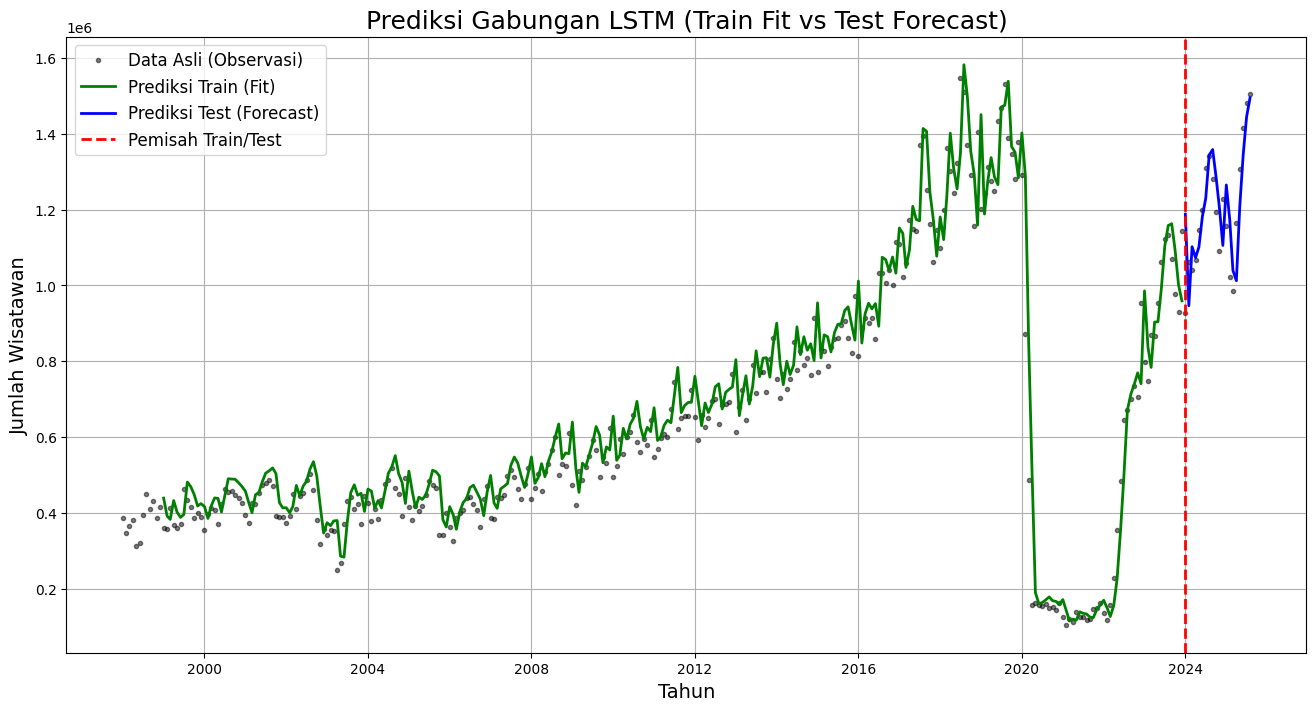

In [ ]:
# 2.1. Siapkan array plot untuk prediksi train
# Buat array kosong seukuran dataset asli, isi dengan NaN
train_predict_plot = np.empty_like(dataset)
train_predict_plot[:, :] = np.nan

# Isi array dengan prediksi train, digeser 'look_back'
train_predict_plot[look_back:len(train_predict_actual) + look_back, :] = train_predict_actual

# 2.2. Siapkan array plot untuk prediksi test
# Buat array kosong seukuran dataset asli, isi dengan NaN
test_predict_plot = np.empty_like(dataset)
test_predict_plot[:, :] = np.nan

# Isi array dengan prediksi test
# 'split_point' adalah indeks di mana data test dimulai
test_predict_plot[split_point:, :] = test_predict_actual

# 2.3. Buat Plot Gabungan
print("Menampilkan Plot Gabungan (Train Fit vs Test Forecast)...")
plt.figure(figsize=(16, 8))

# Plot data asli (Observasi) - SEMUA DATA
plt.plot(dates, dataset, 'k.', label='Data Asli (Observasi)', alpha=0.5)

# Plot prediksi train (In-Sample Fit)
plt.plot(dates, train_predict_plot, 'g-', label='Prediksi Train (Fit)', linewidth=2)

# Plot prediksi test (Out-of-Sample Forecast)
plt.plot(dates, test_predict_plot, 'b-', label='Prediksi Test (Forecast)', linewidth=2)

# Tambahkan garis pemisah train/test
# 'split_date' adalah tanggal, 'split_point' adalah indeks
plt.axvline(x=dates.iloc[split_point], color='r', linestyle='--', linewidth=2, label='Pemisah Train/Test')

plt.title('Prediksi Gabungan LSTM (Train Fit vs Test Forecast)', fontsize=18)
plt.xlabel('Tahun', fontsize=14)
plt.ylabel('Jumlah Wisatawan', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
# 6.1. Buat prediksi pada data test
train_predict_scaled = model.predict(X_train)

# 6.2. Invers-transform: Kembalikan prediksi dari 0-1 ke jumlah wisatawan asli
train_predict_actual = scaler.inverse_transform(train_predict_scaled)

# 6.3. Invers-transform: Kembalikan y_test (data asli)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))

# 6.4. Hitung Metrik Evaluasi
mae_asli = mean_absolute_error(y_train_actual, train_predict_actual)
rmse_asli = np.sqrt(mean_squared_error(y_train_actual, train_predict_actual))
mape_asli = mean_absolute_percentage_error(y_train_actual, train_predict_actual)

print(f"\n--- Metrik Train Set (LSTM) ---")
print(f"MAE (Jumlah Wisatawan): {mae_asli:,.0f}")
print(f"RMSE (Jumlah Wisatawan): {rmse_asli:,.0f}")
print(f"MAPE: {mape_asli * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

--- Metrik Train Set (LSTM) ---
MAE (Jumlah Wisatawan): 57,158
RMSE (Jumlah Wisatawan): 81,295
MAPE: 10.68%


MAPE: 7.48%
RMSE Train : 81295.0285
RMSE Test  : 103007.8757


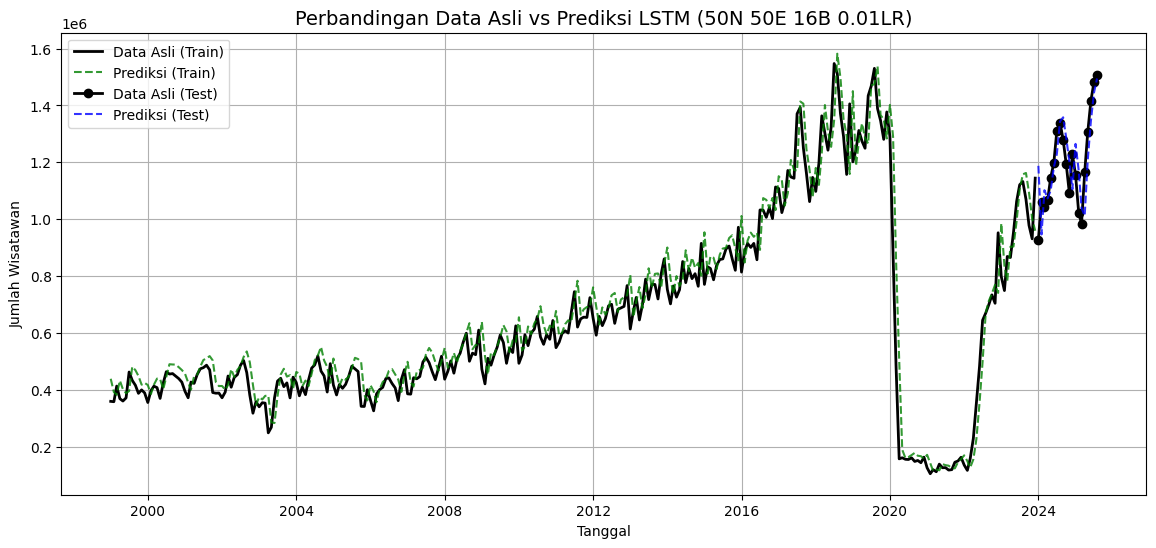

In [ ]:
# === BLOK 8: Evaluasi dan Plot Model Final ===

# Pastikan y_train_actual dan y_test_actual tersedia dari cell sebelumnya
# Atau buat ulang jika cell sebelumnya tidak dijalankan secara berurutan
# Untuk mengantisipasi, kita akan memastikan y_train_actual dan y_test_actual terdefinisi.
# y_test_actual sudah terdefinisi dari proses grid search di cell 1nriXBQZymT8
# Namun y_train_actual belum. Kita definisikan di sini.

# Re-create y_train_actual from the original scaled data for consistency
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))

# 8.1. Prediksi TRAIN dan TEST menggunakan model terbaik
train_predict_scaled = model.predict(X_train, verbose=0)
test_predict_scaled  = model.predict(X_test, verbose=0)

# 🔹 Gunakan scaler yang sudah didefinisikan
train_predict_actual = scaler.inverse_transform(train_predict_scaled)
test_predict_actual  = scaler.inverse_transform(test_predict_scaled)

# 8.2. Bandingkan dengan nilai asli (y_train_actual dan y_test_actual sudah ada)
# y_train_actual dan y_test_actual sudah dihitung di atas/cell sebelumnya

# 8.3. Evaluasi
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict_actual))
test_rmse  = np.sqrt(mean_squared_error(y_test_actual, test_predict_actual))

mape = mean_absolute_percentage_error(y_test_actual, test_predict_actual)
print(f"MAPE: {mape * 100:.2f}%")

print(f"RMSE Train : {train_rmse:.4f}")
print(f"RMSE Test  : {test_rmse:.4f}")

# 8.4. Plot hasil
plt.figure(figsize=(14, 6))
plt.plot(dates.iloc[look_back:split_point], y_train_actual, 'k-', label='Data Asli (Train)', linewidth=2)
plt.plot(dates.iloc[look_back:split_point], train_predict_actual, 'g--', label='Prediksi (Train)', alpha=0.8)
plt.plot(dates.iloc[split_point:], y_test_actual, 'ko-', label='Data Asli (Test)', linewidth=2)
plt.plot(dates.iloc[split_point:], test_predict_actual, 'b--', label='Prediksi (Test)', alpha=0.8)
plt.title(f'Perbandingan Data Asli vs Prediksi LSTM ({best_run["name"]})', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Wisatawan')
plt.legend()
plt.grid(True)
plt.show()

# 9. 🔥 Uji Sisaan (Residuals)

Rata-rata Sisaan: -8,737
Interpretasi: Angka ini harus sedekat mungkin dengan 0.

Menampilkan Histogram Sisaan...


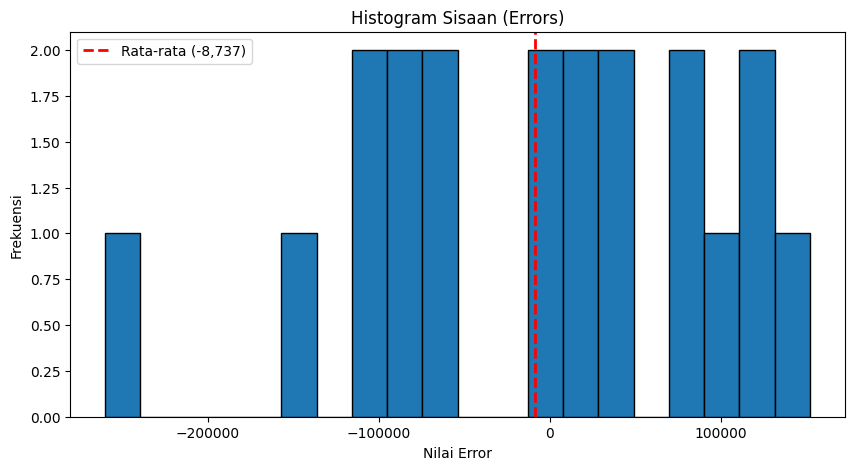


Menampilkan Plot Autokorelasi (ACF) dari Sisaan...


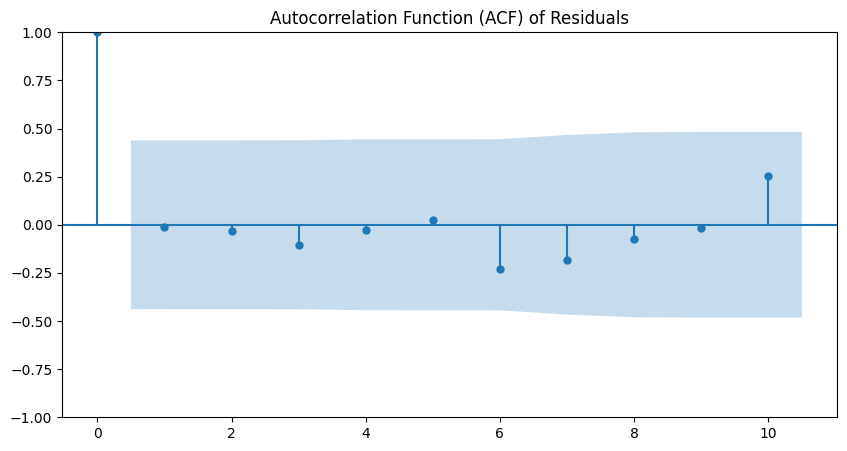

Interpretasi: Jika model 'sempurna', semua batang (lags) harus berada di dalam area biru.
Jika ada batang yang keluar, berarti masih ada pola yang 'tertinggal' (tidak tertangkap model).


In [ ]:
# 1. Hitung Sisaan (Residuals)
# Ini adalah error dari prediksi test set Anda
residuals = y_test_actual - test_predict_actual

# 2. Cek Bias (Harus Mendekati Nol)
print(f"Rata-rata Sisaan: {residuals.mean():,.0f}")
print("Interpretasi: Angka ini harus sedekat mungkin dengan 0.\n")

# 3. Plot Histogram Sisaan (Cek Normalitas & Bias)
print("Menampilkan Histogram Sisaan...")
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=20, edgecolor='k')
plt.title('Histogram Sisaan (Errors)')
plt.xlabel('Nilai Error')
plt.ylabel('Frekuensi')
plt.axvline(residuals.mean(), color='r', linestyle='--', linewidth=2, label=f'Rata-rata ({residuals.mean():,.0f})')
plt.legend()
plt.show()

# 4. Cek Autokorelasi (Harus Acak)
from statsmodels.graphics.tsaplots import plot_acf

print("\nMenampilkan Plot Autokorelasi (ACF) dari Sisaan...")
# Kita hanya punya 12 data test, jadi kita plot 10 lags saja
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals, lags=10, ax=ax) # 'lags' tidak boleh >= jumlah data
plt.title('Autocorrelation Function (ACF) of Residuals')
plt.show()

print("Interpretasi: Jika model 'sempurna', semua batang (lags) harus berada di dalam area biru.")
print("Jika ada batang yang keluar, berarti masih ada pola yang 'tertinggal' (tidak tertangkap model).")

In [ ]:
# Export data fitted ke xlsx
test_predict_actual_df = pd.DataFrame(test_predict_actual, columns=['Prediksi'])
test_predict_actual_df.to_excel('test_predict_actual.xlsx', index=False)

# 🧠 Kode Tuning LSTM (Epochs=150)

In [ ]:
# 1. 🧱 MEMBANGUN ULANG ARSITEKTUR MODEL
print("Membangun ulang arsitektur model...")
model_tuned = Sequential()

# Layer pertama
model_tuned.add(LSTM(100, return_sequences=True, input_shape=(look_back, 1)))

# Layer kedua (sebagai layer terakhir LSTM)
model_tuned.add(LSTM(50))

model_tuned.add(Dense(1))
model_tuned.compile(loss='mean_squared_error', optimizer='adam')

print("\nRingkasan Model:")
model_tuned.summary()

# 2. 🚂 MELATIH ULANG MODEL DENGAN EPOCHS LEBIH BANYAK
print("\nMelatih model (Tuned) dengan epochs=150...")
# X_train, y_train, X_test, y_test seharusnya sudah ada dari script sebelumnya
history_tuned = model_tuned.fit(
    X_train,
    y_train,
    epochs=150,  # <-- Disesuaikan menjadi 150
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
    shuffle=False
)

# 3. 🔮 MEMBUAT PREDIKSI BARU
print("\nMembuat prediksi baru dengan model yang di-tuning...")
test_predict_scaled_tuned = model_tuned.predict(X_test)

# 4. 🔄 INVERS-TRANSFORM HASIL BARU
# Kembalikan prediksi dari 0-1 ke jumlah wisatawan asli
test_predict_actual_tuned = scaler.inverse_transform(test_predict_scaled_tuned)
# y_test_actual (data asli) masih sama, tidak perlu dibuat ulang

# 5. 📊 EVALUASI ULANG METRIK
mae_tuned = mean_absolute_error(y_test_actual, test_predict_actual_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_actual, test_predict_actual_tuned))
mape_tuned = mean_absolute_percentage_error(y_test_actual, test_predict_actual_tuned)

print(f"\n--- Metrik Test Set (HASIL TUNING) ---")
print(f"MAPE: {mape_tuned * 100:.2f}%")
print(f"MAE (Jumlah Wisatawan): {mae_tuned:,.0f}")
print(f"RMSE (Jumlah Wisatawan): {rmse_tuned:,.0f}")

# 6. 🔬 ANALISIS SISAAN BARU
print("\n--- Analisis Sisaan (HASIL TUNING) ---")
residuals_tuned = y_test_actual - test_predict_actual_tuned

# Cek Bias (Harus Mendekati Nol)
print(f"Rata-rata Sisaan BARU: {residuals_tuned.mean():,.0f}")

# --- (Saya hapus perbandingan lama jika variabel 'residuals' tidak ada) ---
# print("==================================================")
# print(f"Rata-rata Sisaan LAMA: {residuals.mean():,.0f}")
# print("==================================================")
# print("Interpretasi: Apakah rata-rata baru lebih dekat ke 0?\n")

# Plot Histogram Sisaan BARU
print("Menampilkan Histogram Sisaan BARU...")
plt.figure(figsize=(10, 5))
plt.hist(residuals_tuned, bins=20, edgecolor='k')
plt.title('Histogram Sisaan BARU (Tuned Model)')
plt.xlabel('Nilai Error')
plt.ylabel('Frekuensi')
plt.axvline(residuals_tuned.mean(), color='r', linestyle='--', linewidth=2, label=f'Rata-rata ({residuals_tuned.mean():,.0f})')
plt.legend()
plt.show()

# Plot ACF Sisaan BARU
print("\nMenampilkan Plot ACF Sisaan BARU...")
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals_tuned, lags=10, ax=ax)
plt.title('ACF Sisaan BARU (Tuned Model)')
plt.show()

# 7. 📈 == KODE BARU: PLOT TRAINING vs VALIDATION LOSS ==
print("\nMenampilkan plot Training Loss vs Validation Loss...")

# Ambil data loss dari history
training_loss = history_tuned.history['loss']
validation_loss = history_tuned.history['val_loss']

# Buat rentang epochs
epochs = range(1, len(training_loss) + 1)

# Buat plot
plt.figure(figsize=(12, 6))

plt.plot(epochs, training_loss, 'g-', label='Training Loss (loss)')
plt.plot(epochs, validation_loss, 'b-', label='Validation Loss (val_loss)')

plt.title('Training & Validation Loss Selama Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Interpretasi Plot Loss ---")
print("1. Jika Garis Biru (val_loss) Mulai NAIK sementara Hijau (loss) TURUN: Ini adalah OVERFITTING.")
print("2. Jika Garis Biru NAIK di akhir: Ini menjelaskan mengapa prediksi masa depan 'terjun bebas'.")

# 🔮 Prediksi Masa Depan (12 Bulan)

In [ ]:
# 1. Tentukan berapa langkah ke depan kita akan prediksi
n_future = 16
look_back = 12 # Harus sama dengan yang kita gunakan untuk melatih

# 2. Dapatkan 12 data terakhir (scaled) dari dataset LENGKAP
# Ini adalah input pertama kita untuk memprediksi masa depan
full_scaled_dataset = scaler.transform(dataset)
last_12_steps_scaled = full_scaled_dataset[-look_back:]

# Reshape untuk input model
current_input = last_12_steps_scaled.reshape((1, look_back, 1))

# 3. List untuk menyimpan prediksi
future_predictions_scaled = []

print(f"Membuat {n_future} prediksi masa depan (rolling forecast)...")

for i in range(n_future):
    # Dapatkan prediksi (scaled)
    pred_scaled = model_tuned.predict(current_input)[0][0]

    # Simpan prediksi
    future_predictions_scaled.append(pred_scaled)

    # Siapkan input baru: 'geser' window
    # Hapus data pertama, tambahkan prediksi baru di akhir
    new_input_step = np.array([[pred_scaled]])
    current_input = np.concatenate((current_input[:, 1:, :], new_input_step.reshape(1,1,1)), axis=1)

print("Prediksi masa depan selesai.")

# 4. Invers-transform: Kembalikan prediksi masa depan ke jumlah wisatawan
future_predictions_actual = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

In [ ]:
# 5. Buat tanggal untuk masa depan
# 'dates' adalah variabel dari script sebelumnya
last_date = dates.iloc[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_future, freq='MS') # 'MS' = Month Start

# 6. Tampilkan sebagai DataFrame
df_future = pd.DataFrame(data={
    'Tanggal': future_dates,
    'Prediksi_Wisatawan': future_predictions_actual.flatten()
})

print("\n--- NILAI PREDIKSI 12 BULAN KE DEPAN ---")
print(df_future)

In [ ]:
# 7. Siapkan array plot untuk SEMUA prediksi
# (Menggunakan model_tuned yang sudah dilatih)

# 7.1. Prediksi Train
train_predict_scaled_tuned = model_tuned.predict(X_train)
train_predict_actual = scaler.inverse_transform(train_predict_scaled_tuned)

# 7.2. Prediksi Test
test_predict_scaled_tuned = model_tuned.predict(X_test)
test_predict_actual = scaler.inverse_transform(test_predict_scaled_tuned)

# 7.3. Buat array plot (Train, Test, Future)
total_size = len(dataset) + n_future
all_dates = pd.date_range(start=dates.iloc[0], periods=total_size, freq='MS')

# Plot untuk Train
train_predict_plot = np.empty((total_size, 1))
train_predict_plot[:, :] = np.nan
train_predict_plot[look_back:len(train_predict_actual) + look_back, :] = train_predict_actual

# Plot untuk Test
test_predict_plot = np.empty((total_size, 1))
test_predict_plot[:, :] = np.nan
test_predict_plot[len(train_predict_actual) + look_back : len(dataset), :] = test_predict_actual # <-- Disesuaikan

# Plot untuk Future
future_predict_plot = np.empty((total_size, 1))
future_predict_plot[:, :] = np.nan
future_predict_plot[len(dataset):, :] = future_predictions_actual

# 7.4. Buat Plot Gabungan
print("\nMenampilkan Plot Gabungan (Train + Test + Future)...")
plt.figure(figsize=(20, 10))

# Plot data asli (Observasi)
plt.plot(all_dates[:len(dataset)], dataset, 'k.', label='Data Asli (Observasi)', alpha=0.5)

# Plot prediksi train (In-Sample Fit)
plt.plot(all_dates, train_predict_plot, 'g-', label='Prediksi Train (Fit)', linewidth=2)

# Plot prediksi test (Out-of-Sample Forecast)
plt.plot(all_dates, test_predict_plot, 'b-', label='Prediksi Test (Forecast)', linewidth=2)

# Plot prediksi future (New Forecast)
plt.plot(all_dates, future_predict_plot, 'r-', label='Prediksi Masa Depan (Future)', linewidth=2)

# Garis pemisah train/test
plt.axvline(x=dates.iloc[split_point], color='grey', linestyle='--', linewidth=2, label='Pemisah Train/Test')

plt.title('Prediksi Gabungan LSTM (Train + Test + Future)', fontsize=18)
plt.xlabel('Tahun', fontsize=14)
plt.ylabel('Jumlah Wisatawan', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()